In [1]:
# Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import lightgbm as lgb

# Load the master dataset from Notebook 3
df = pd.read_csv('data/final_modeling_data.csv')

# Drop columns that aren't features (IDs, Titles, Descriptions)
cols_to_drop = ['book_id', 'title', 'authors', 'publisher', 'title_clean', 'description']
X = df.drop(columns=cols_to_drop + ['bestseller'])
y = df['bestseller']

# Train/Test Split (80/20) - Stratified because bestsellers are rare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Bestseller count in test set: {y_test.sum()}")

Training set size: (366812, 9)
Bestseller count in test set: 5614


In [3]:
# The "Safety Imputer"
# Check which columns have NaNs (just for your own info)
print("Columns with missing values:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# Fill all remaining NaNs in X_train and X_test with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("\nNaNs cleared. Re-running Logistic Regression...")

Columns with missing values:
average_rating        2
ratings_count         2
text_reviews_count    2
dtype: int64

NaNs cleared. Re-running Logistic Regression...


Every good project needs a baseline to prove the advanced model is actually better.

In [4]:
# Baseline Model (Logistic Regression)
print("Training Logistic Regression Baseline...")
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)
baseline_probs = baseline.predict_proba(X_test)[:, 1]

print(f"Baseline AUC-ROC: {roc_auc_score(y_test, baseline_probs):.4f}")
print(f"Baseline F1-Score: {f1_score(y_test, baseline_preds):.4f}")

Training Logistic Regression Baseline...
Baseline AUC-ROC: 0.6144
Baseline F1-Score: 0.0193


This is the core model from our group project. We use scale_pos_weight to handle the class imbalance (since most books are not bestsellers).

In [5]:
# The Primary Model (LightGBM)
# Calculate the ratio for imbalance handling
ratio = (len(y_train) - y_train.sum()) / y_train.sum()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=ratio, # Critical for imbalanced data
    random_state=42
)

lgbm_model.fit(X_train, y_train)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

print(f"LightGBM AUC-ROC: {roc_auc_score(y_test, lgbm_probs):.4f}")

[LightGBM] [Info] Number of positive: 22456, number of negative: 344356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 366812, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061219 -> initscore=-2.730118
[LightGBM] [Info] Start training from score -2.730118
LightGBM AUC-ROC: 0.6990


Our report highlights Precision@100. This is a business-centric metric: "If we recommend the top 100 books the model is most confident in, how many are actually bestsellers?"

In [6]:
# Precision@K Evaluation
def precision_at_k(y_true, y_probs, k):
    # Sort by probability in descending order
    df_results = pd.DataFrame({'true': y_true, 'prob': y_probs})
    top_k = df_results.sort_values(by='prob', ascending=False).head(k)
    return top_k['true'].mean()

p100 = precision_at_k(y_test, lgbm_probs, 100)
p500 = precision_at_k(y_test, lgbm_probs, 500)

print(f"Precision@100: {p100:.2%}")
print(f"Precision@500: {p500:.2%}")

Precision@100: 58.00%
Precision@500: 44.20%


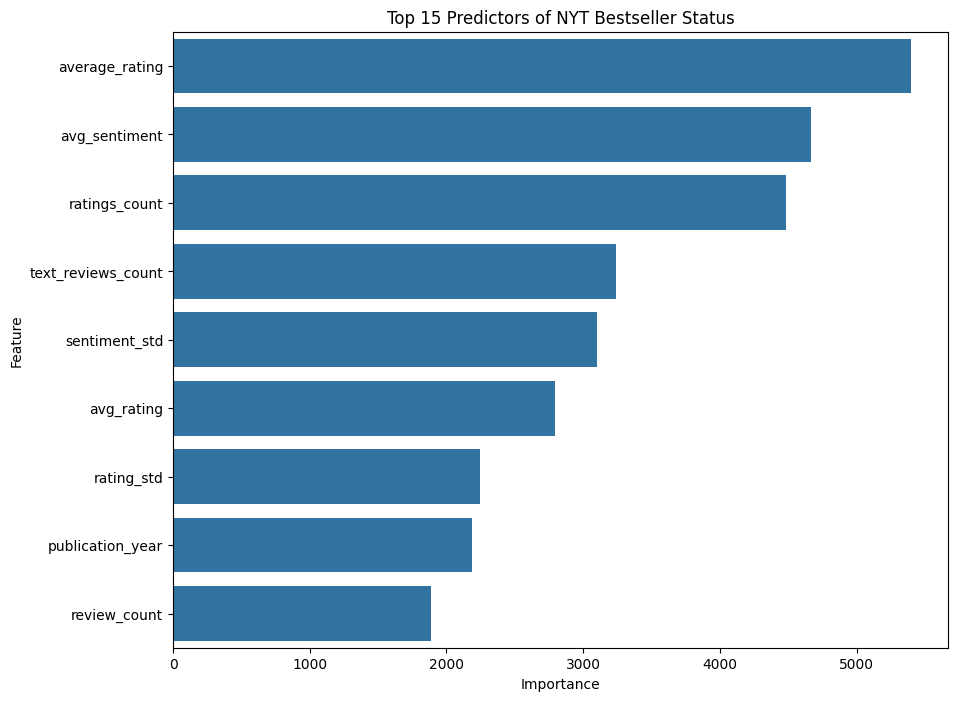

In [7]:
# Feature Importance Visualization
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Predictors of NYT Bestseller Status')
plt.show()